# Exploring the data 

Load in all of the data and rasters that we have from the previous step. 

We'll focus on just the lowman data for now. 

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
import gc

In [2]:
data_dir = '../data/' # on local machine
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
data_file = 'stacks/mores_creek/'

all_data = xr.open_zarr(data_dir + data_file)
# drop crs data var
all_data = all_data.drop_vars('crs')
print(all_data.data_vars)

Data variables:
    acq_day_precip      (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    aspect              (y, x) float32 212kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    avg_precip          (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_rain            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_snow            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    big_accum           (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    canopy_2019         (y, x) float32 212kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    coherence           (flight_id, pair, y, x) float32 33MB dask.array<chunksize=(1, 20, 101, 131), meta=np.ndarray>
    cover_2019          (y, x) float64 423kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    curve               (y, x) float32 212kB dask.array<chunksize=

In [ ]:
# list(data.data_vars)

['acq_day_precip',
 'aspect',
 'avg_precip',
 'avg_rain',
 'avg_snow',
 'big_accum',
 'canopy_2019',
 'coherence',
 'cover_2019',
 'curve',
 'density_change',
 'diurnal_temp_range',
 'elevation',
 'freeze_thaw_cycles',
 'incidence_angle',
 'max_temp',
 'max_wind',
 'mean_temp',
 'mean_wind',
 'slope',
 'snow_class',
 'snow_status_change',
 'swe_ablate',
 'swe_accum',
 'temp_diff',
 'temp_diff_acq',
 'total_posdeg',
 'total_precip',
 'total_rain',
 'total_snow']

In [3]:
cols = ['acq_day_precip',
        'aspect',
        'avg_precip',
        'avg_rain',
        'avg_snow',
        'canopy_2019',
        'coherence',
        'curve',
        'density_change',
        'diurnal_temp_range',
        'elevation',
        'incidence_angle',
        'max_temp',
        'max_wind',
        'mean_temp',
        'mean_wind',
        'slope',
        'swe_ablate',
        'swe_accum',
        'temp_diff',
        'temp_diff_acq',
        'total_posdeg',
        ]
data = all_data[cols]

Static variables: ['aspect', 'canopy_2019', 'curve', 'elevation', 'incidence_angle', 'slope']
Pair variables: ['acq_day_precip', 'avg_precip', 'avg_rain', 'avg_snow', 'coherence', 'density_change', 'diurnal_temp_range', 'max_temp', 'max_wind', 'mean_temp', 'mean_wind', 'swe_ablate', 'swe_accum', 'temp_diff', 'temp_diff_acq', 'total_posdeg']


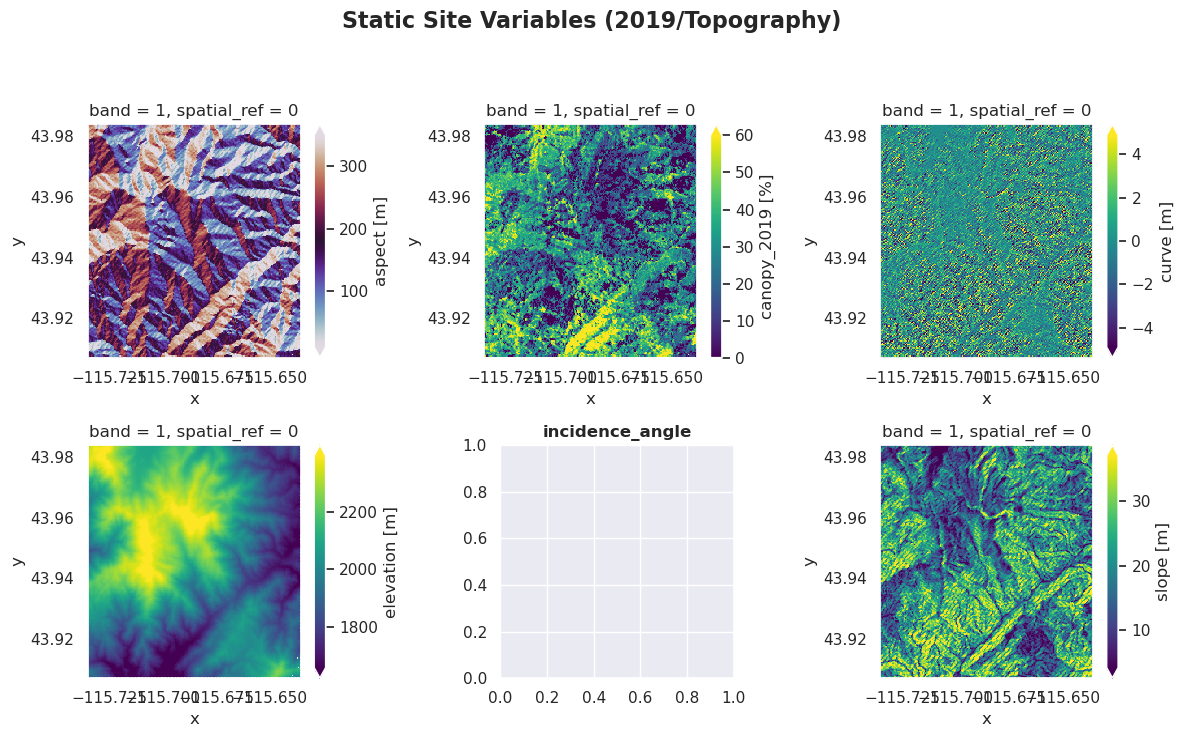

In [17]:
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
print("Static variables:", static_vars)
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]
print("Pair variables:", pair_vars)

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    if 'flight_id' not in data[var].dims:
        data[var].plot(ax=ax, robust=True, cmap=cmap) 
        # ax.axis_off()
        continue

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data


# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [6]:
# 3. Flatten into ML-ready format
data_array = data.to_array(dim='variable')  # (variable, pair, flightnum, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,acq_day_precip,aspect,avg_precip,avg_rain,avg_snow,canopy_2019,coherence,curve,density_change,diurnal_temp_range,elevation,incidence_angle,max_temp,max_wind,mean_temp,mean_wind,slope,swe_ablate,swe_accum,temp_diff,temp_diff_acq,total_posdeg
acq_day_precip,1.000000,0.007755,0.164616,-0.131894,0.196795,0.002072,-0.035552,0.000083,-0.115796,-0.160529,0.033414,-0.023569,-0.123125,0.042558,-0.136624,0.133101,-0.009148,-0.114313,0.199514,0.007312,-0.126934,-0.101509
aspect,0.007755,1.000000,0.019777,-0.038991,0.032054,0.165030,0.021231,0.010412,-0.002551,-0.052560,0.074032,-0.071340,-0.009852,0.071930,-0.018697,0.113917,0.051162,0.067525,0.068724,-0.004075,0.004768,-0.009803
avg_precip,0.164616,0.019777,1.000000,-0.076286,0.932051,-0.009426,-0.226333,-0.000135,-0.100082,-0.220474,0.154720,0.011562,-0.015304,0.316141,-0.172153,0.344032,-0.031136,-0.181545,0.698740,0.170993,-0.007133,-0.043149
avg_rain,-0.131894,-0.038991,-0.076286,1.000000,-0.432374,0.006817,-0.279230,-0.000716,-0.301122,0.666831,-0.318983,-0.049123,0.726116,0.257693,0.809417,-0.416129,0.088535,0.475304,-0.547769,-0.317118,-0.115087,0.767480
avg_snow,0.196795,0.032054,0.932051,-0.432374,1.000000,-0.011001,-0.103211,0.000138,0.018916,-0.441698,0.255831,0.028307,-0.277700,0.192254,-0.449814,0.462333,-0.060330,-0.336895,0.830943,0.269871,0.035370,-0.317913
canopy_2019,0.002072,0.165030,-0.009426,0.006817,-0.011001,1.000000,-0.067294,0.037347,0.005719,-0.033548,-0.117915,-0.054564,0.001190,-0.001232,0.015319,-0.016951,0.027387,0.006956,0.000013,-0.001677,-0.015882,0.008227
coherence,-0.035552,0.021231,-0.226333,-0.279230,-0.103211,-0.067294,1.000000,0.022906,-0.012896,-0.228483,0.025955,0.076822,-0.377475,-0.354353,-0.309058,0.012409,0.024393,-0.152259,0.021778,0.028063,0.081151,-0.340603
curve,0.000083,0.010412,-0.000135,-0.000716,0.000138,0.037347,0.022906,1.000000,-0.001001,-0.000162,0.051656,-0.013137,0.000189,0.000698,0.000294,0.000665,0.010441,0.002863,0.003211,0.000205,0.000285,0.000143
density_change,-0.115796,-0.002551,-0.100082,-0.301122,0.018916,0.005719,-0.012896,-0.001001,1.000000,-0.153827,-0.053777,-0.026872,-0.317591,-0.238903,-0.377713,-0.031920,0.028045,-0.142132,0.149458,0.358515,-0.000142,-0.424761
diurnal_temp_range,-0.160529,-0.052560,-0.220474,0.666831,-0.441698,-0.033548,-0.228483,-0.000162,-0.153827,1.000000,-0.445549,-0.072458,0.738216,0.119815,0.756212,-0.635374,0.109447,0.301317,-0.565783,-0.074693,-0.106749,0.713137


In [13]:
# make a variable statistics table and print
stats_df = pd.DataFrame({
    'Variable': data.data_vars,
    'Min': [data[var].min().values for var in data.data_vars],
    'Max': [data[var].max().values for var in data.data_vars],
    'Mean': [data[var].mean().values for var in data.data_vars],
    'Std Dev': [data[var].std().values for var in data.data_vars],
    'Num nans': [data[var].isnull().sum().values for var in data.data_vars]
})
# print with only 2 decimal places for readability
stats_df.style.format({'Min': '{:.3f}', 'Max': '{:.3f}', 'Mean': '{:.3f}', 'Std Dev': '{:.3f}'})


,Variable,Min,Max,Mean,Std Dev,Num nans
0,acq_day_precip,0.000,0.800,0.173,0.311,548709
1,aspect,0.030,359.995,175.668,94.438,26105
2,avg_precip,0.000,0.216,0.104,0.057,548709
3,avg_rain,0.000,0.096,0.008,0.016,548709
4,avg_snow,0.000,0.216,0.096,0.061,548709
5,canopy_2019,0.000,77.000,23.557,16.551,26105
6,coherence,0.002,0.903,0.248,0.153,548205
7,curve,-11.581,10.753,0.010,2.270,26105
8,density_change,-0.055,0.257,0.053,0.037,549087
9,diurnal_temp_range,4.088,11.829,7.242,1.382,548709


In [14]:

def plot_spatial_avg_vs_target(ds: xr.Dataset, target_var: str = 'coherence', ncols: int = 5):
    """
    Computes the spatial mean (over x and y) of an xarray Dataset and 
    plots the resulting pairs as scatter plots against a target variable.
    
    Parameters:
    - ds: xarray.Dataset containing the data cube.
    - target_var: The variable to plot on the y-axis (default: 'coherence').
    - ncols: Number of columns for the subplot grid (default: 5).
    """
    # 1. Identify variables to plot
    if target_var not in ds.data_vars:
        raise ValueError(f"Target variable '{target_var}' not found in the dataset.")
        
    vars_to_plot = [var for var in ds.data_vars if var != target_var]
    n_vars = len(vars_to_plot)
    
    # Calculate required rows
    nrows = math.ceil(n_vars / ncols)
    
    # 2. Perform Spatial Averaging & Flatten
    cols_to_keep = vars_to_plot + [target_var]
    
    # .mean(dim=['x', 'y']) averages the spatial dimensions.
    # .squeeze() drops the 'flight_id' dimension since its length is only 1.
    # .compute() triggers Dask to do the math efficiently before moving to Pandas.
    df = ds[cols_to_keep].mean(dim=['x', 'y']).squeeze().compute().to_dataframe().dropna()
    
    # 3. Setup the figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    
    if n_vars == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    # 4. Generate the Scatter Plots
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        # Standard scatter plot
        ax.scatter(
            x=df[var], 
            y=df[target_var], 
            alpha=0.7,
            edgecolors='white',  # Adds a nice border to the points
            s=50,                # Point size
            color='#2b7bba'      # Using the nice blue from your first snippet!
        )
        
        ax.set_xlabel(var)
        ax.set_ylabel(target_var)
        ax.set_title(f'{var} vs {target_var}')
        ax.grid(True, linestyle='--', alpha=0.5) # Optional: adds a light grid for readability
        
    # Hide any leftover empty subplots in the grid
    for j in range(n_vars, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 5. Memory Cleanup
    del df
    gc.collect()

def plot_cube_vs_target(ds: xr.Dataset, target_var: str = 'coherence', ncols: int = 5, gridsize: int = 50):
    """
    Plots variables in an xarray Dataset against a target variable using hexbin density plots.
    
    Parameters:
    - ds: xarray.Dataset containing the data cube.
    - target_var: The variable to plot on the y-axis (default: 'coherence').
    - ncols: Number of columns for the subplot grid (default: 5).
    - gridsize: The number of hexagons in the x-direction (default: 50).
    """
    # 1. Identify variables to plot (exclude the target variable itself)
    if target_var not in ds.data_vars:
        raise ValueError(f"Target variable '{target_var}' not found in the dataset.")
        
    vars_to_plot = [var for var in ds.data_vars if var != target_var]
    n_vars = len(vars_to_plot)
    
    # Calculate required rows based on number of variables and requested columns
    nrows = math.ceil(n_vars / ncols)
    
    # 2. Flatten Data: Convert to DataFrame and drop NaNs
    # We only convert the variables we actually need to save memory
    cols_to_keep = vars_to_plot + [target_var]
    df = ds[cols_to_keep].to_dataframe().dropna()
    
    # 3. Setup the figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    # Flatten axes array for easy 1D iteration (handles cases where nrows=1 or ncols=1)
    if n_vars == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    # 4. Generate the Hexbin Plots
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        # Create the hexbin plot
        hb = ax.hexbin(
            x=df[var], 
            y=df[target_var], 
            gridsize=gridsize, 
            cmap='viridis', 
            mincnt=1,      # Only color hexagons that contain at least 1 point
            # bins='log'     # Use logarithmic color scaling for highly dense data
        )
        
        ax.set_xlabel(var)
        ax.set_ylabel(target_var)
        ax.set_title(f'{var} vs {target_var}')
        
        # Add a localized colorbar for each subplot
        cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
        # cb.set_label('log10(N)')
        
    # Hide any leftover empty subplots in the grid
    for j in range(n_vars, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 5. Memory Cleanup
    # Explicitly delete the large DataFrame and force python to run garbage collection
    del df
    gc.collect()

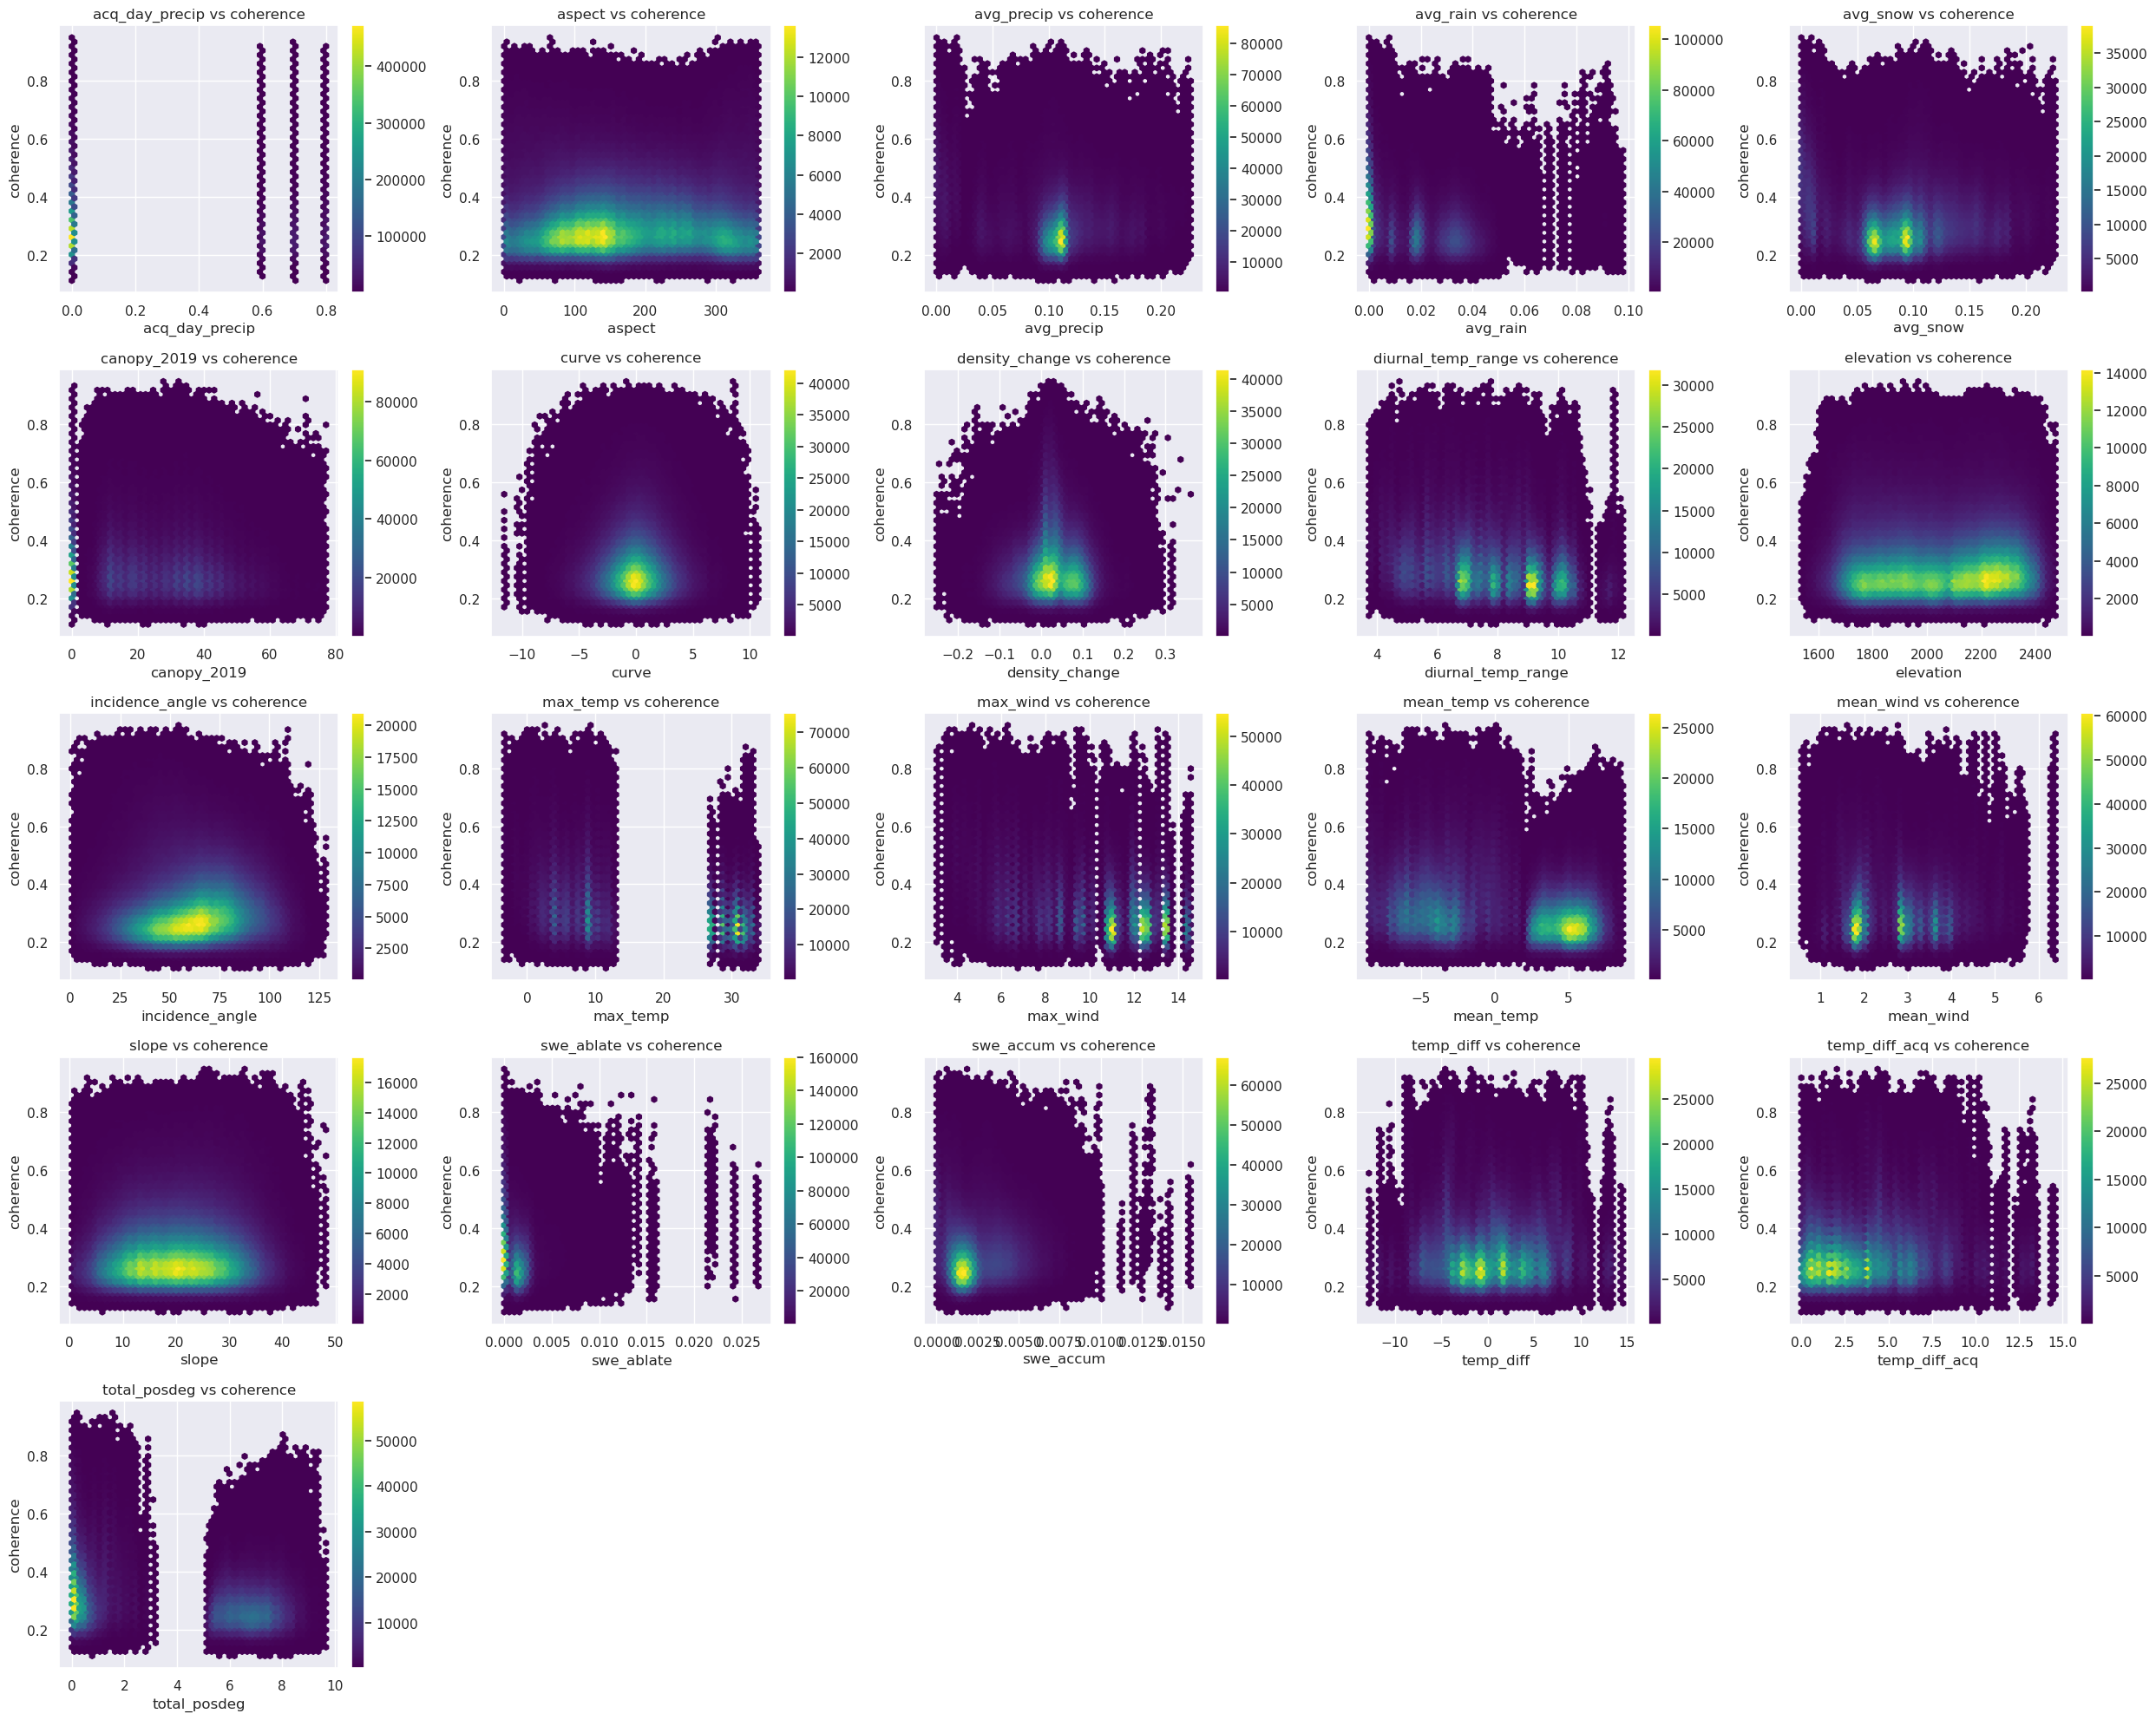

In [15]:
plot_cube_vs_target(data)

# Looking at flight quality 

In [45]:
ann_dir = Path(data_dir + 'uavsar_slcs/lowman/05208')
anns = sorted(list(ann_dir.glob(f'*05208*ann')))

from uavsar_pytools.convert.tiff_conversion import read_annotation

dates = []
yaws = []
pitches = []
for ann in anns: 
    d = read_annotation(ann)
    d = pd.DataFrame(d).T
    timestamp = d.loc['start time of acquisition', 'value']
    print(timestamp)
    dates.append(timestamp)
    yaw = d.loc['global average yaw', 'value']
    print(yaw)
    yaws.append(yaw)
    pitch = d.loc['global average pitch', 'value']
    print(pitch)
    pitches.append(pitch)

2020-01-31 14:10:44-07:00
-3.46140426
1.20923647
2020-02-13 13:27:17-07:00
-3.46140426
1.20923647
2020-02-20 18:34:39-07:00
-3.46140426
1.20923647
2020-03-11 11:25:50-06:00
-3.46140426
1.20923647
2021-02-03 13:16:28-07:00
-3.46140426
1.20923647
2021-02-10 16:06:16-07:00
-3.46140426
1.20923647
2021-03-03 11:28:34-07:00
-3.46140426
1.20923647
2021-03-10 11:03:07-07:00
-3.46140426
1.20923647
2021-03-16 12:09:25-06:00
-3.46140426
1.20923647
2021-03-22 10:58:31-06:00
-3.46140426
1.20923647


In [42]:
print(yaws)

[-3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426, -3.46140426]


## Simple linear model 


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

R² score for linear regression: 0.325
RMSE for linear regression: 0.126
MSE for linear regression: 0.016


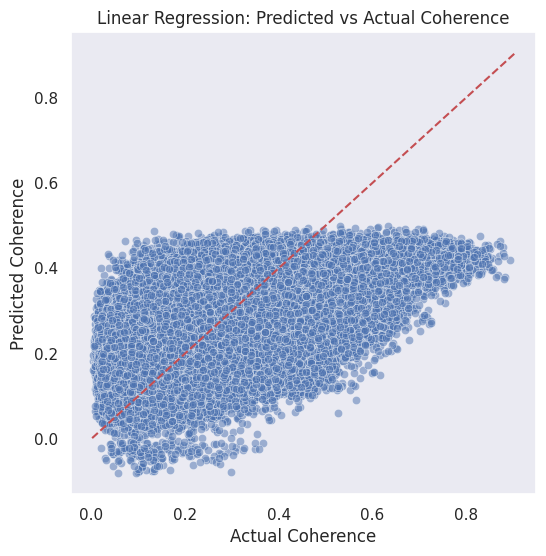

               Feature  Coefficient
11            max_temp    -4.35e-02
7       density_change    -4.19e-02
2           avg_precip    -3.28e-02
3             avg_rain    -2.98e-02
12            max_wind    -2.30e-02
4             avg_snow    -2.29e-02
5          canopy_2019    -1.43e-02
0       acq_day_precip     1.42e-02
19       temp_diff_acq     1.40e-02
14           mean_wind     1.24e-02
9            elevation    -1.08e-02
8   diurnal_temp_range     1.04e-02
18           temp_diff    -8.40e-03
13           mean_temp    -4.82e-03
17           swe_accum    -4.38e-03
1               aspect    -4.34e-03
10     incidence_angle    -3.45e-03
20        total_posdeg     2.77e-03
16          swe_ablate    -2.54e-03
15               slope     2.15e-03
6                curve     1.67e-03


In [15]:
# get column index of coherence 
c_idx = list(data.data_vars).index('coherence')
all_other_idxs = [i for i in range(len(data.data_vars)) if i != c_idx]

# Define features and target
X = data_clean[:, all_other_idxs]  # all variables except coherence
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R² score for linear regression: {r2:.3f}')
print(f'RMSE for linear regression: {rmse:.3f}')
print(f'MSE for linear regression: {mse:.3f}')

# Plot predicted vs actual coherence
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Linear Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()

# Feature importance (coefficients) from linear regression
feature_names = [v for v in data.data_vars if v != 'coherence']
coefficients = model.coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print(coef_df[['Feature', 'Coefficient']])


# Simple decision tree

R² score for decision tree regression: 0.492
RMSE for decision tree regression: 0.109
MSE for decision tree regression: 0.012


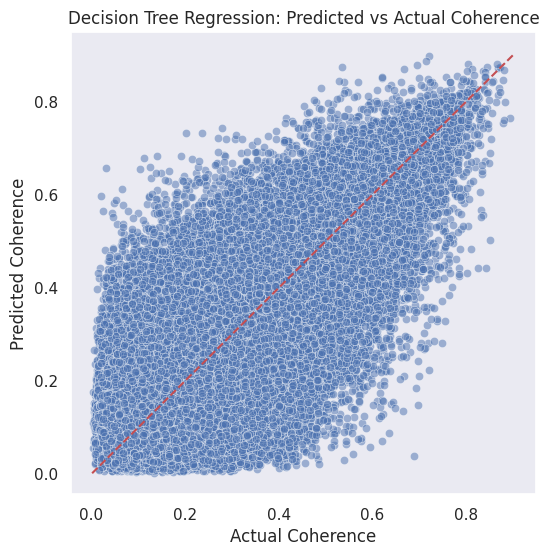

               Feature  Importance
2           avg_precip    1.60e-01
11            max_temp    1.51e-01
9            elevation    9.15e-02
4             avg_snow    8.36e-02
1               aspect    6.60e-02
7       density_change    6.29e-02
15               slope    5.20e-02
12            max_wind    4.52e-02
10     incidence_angle    4.27e-02
19       temp_diff_acq    4.23e-02
6                curve    4.14e-02
5          canopy_2019    3.61e-02
17           swe_accum    2.89e-02
18           temp_diff    2.59e-02
14           mean_wind    2.47e-02
16          swe_ablate    1.44e-02
3             avg_rain    1.06e-02
13           mean_temp    8.07e-03
8   diurnal_temp_range    6.09e-03
0       acq_day_precip    3.64e-03
20        total_posdeg    2.68e-03


In [37]:
# make a decision tree regressor and evaluate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# redefine features and target for decision tree
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_tree = tree_model.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f'R² score for decision tree regression: {r2_tree:.3f}')
print(f'RMSE for decision tree regression: {rmse_tree:.3f}')
print(f'MSE for decision tree regression: {mse_tree:.3f}')

# Plot predicted vs actual coherence for decision tree
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Decision Tree Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()  

# Feature importance from decision tree
feature_names = [v for v in data.data_vars if v != 'coherence']
importances = tree_model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)


# Random forest

R² score for random forest regression: 0.708
RMSE for random forest regression: 0.083
MSE for random forest regression: 0.007


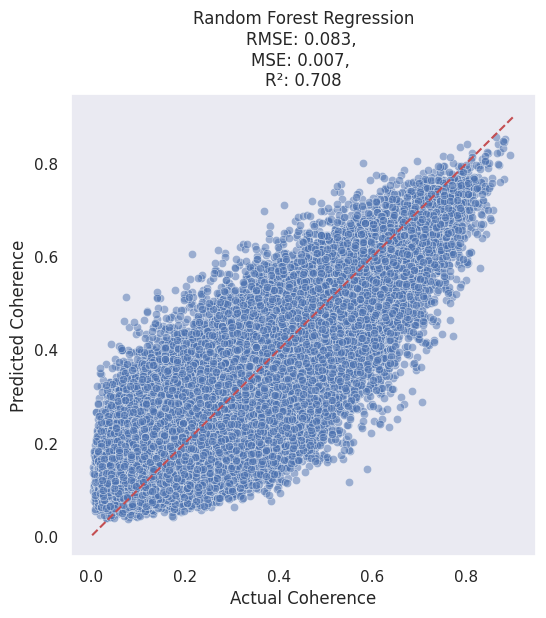

               Feature  Importance
2           avg_precip    1.88e-01
11            max_temp    1.51e-01
9            elevation    8.64e-02
1               aspect    6.42e-02
7       density_change    6.31e-02
15               slope    5.17e-02
4             avg_snow    5.11e-02
12            max_wind    4.56e-02
10     incidence_angle    4.53e-02
6                curve    4.38e-02
19       temp_diff_acq    4.37e-02
5          canopy_2019    3.63e-02
17           swe_accum    2.99e-02
18           temp_diff    2.48e-02
14           mean_wind    2.40e-02
16          swe_ablate    1.44e-02
3             avg_rain    1.09e-02
13           mean_temp    8.95e-03
0       acq_day_precip    7.23e-03
8   diurnal_temp_range    6.35e-03
20        total_posdeg    2.42e-03


In [20]:
# make a random forest model and evaluate
from sklearn.ensemble import RandomForestRegressor

# redefine features and target for random forest
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Train random forest regressor
rf_model = RandomForestRegressor(n_estimators=10, 
                                #  max_depth=10,
                                 criterion='squared_error',
                                 random_state=42,
                                 n_jobs=-1,
                                 )
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'R² score for random forest regression: {r2_rf:.3f}')
print(f'RMSE for random forest regression: {rmse_rf:.3f}')
print(f'MSE for random forest regression: {mse_rf:.3f}')

# Plot predicted vs actual coherence for random forest
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title(f'Random Forest Regression\nRMSE: {rmse_rf:.3f}, \nMSE: {mse_rf:.3f}, \nR²: {r2_rf:.3f}')
plt.grid()
plt.show() 

# Feature importance from random forest
feature_names = [v for v in data.data_vars if v != 'coherence']
importances_rf = rf_model.feature_importances_
importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
importance_rf_df = importance_rf_df.sort_values('Importance', ascending=False)
print(importance_rf_df)

In [30]:
from sklearn.inspection import permutation_importance

r = permutation_importance(rf_model, X_test, y_pred_rf,
                           n_repeats=5,
                           random_state=42)


In [42]:
for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{feature_names[i]:<22}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

max_temp              0.771 +/- 0.003
avg_precip            0.700 +/- 0.003
density_change        0.318 +/- 0.001
temp_diff_acq         0.244 +/- 0.001
elevation             0.219 +/- 0.001
temp_diff             0.209 +/- 0.000
avg_snow              0.169 +/- 0.001
max_wind              0.153 +/- 0.002
mean_wind             0.147 +/- 0.001
swe_accum             0.129 +/- 0.001
aspect                0.104 +/- 0.000
avg_rain              0.089 +/- 0.001
swe_ablate            0.062 +/- 0.000
slope                 0.059 +/- 0.000
mean_temp             0.057 +/- 0.000
canopy_2019           0.048 +/- 0.000
incidence_angle       0.043 +/- 0.000
acq_day_precip        0.035 +/- 0.000
curve                 0.034 +/- 0.000
diurnal_temp_range    0.034 +/- 0.000
total_posdeg          0.012 +/- 0.000


20 8 6 0 10 5 13 15 16 3 1 17 14 12 4 18 9 19 7 2 11


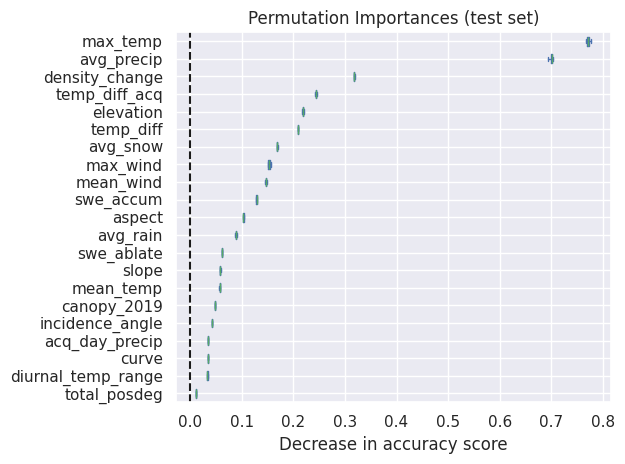

In [61]:
sorted_r = r.importances_mean.argsort()
print(*sorted_r)
importances = pd.DataFrame(
    r.importances[sorted_r].T,
    columns=np.array(feature_names)[sorted_r],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

R² score for random forest regression: 0.590
RMSE for random forest regression: 0.098
MSE for random forest regression: 0.010


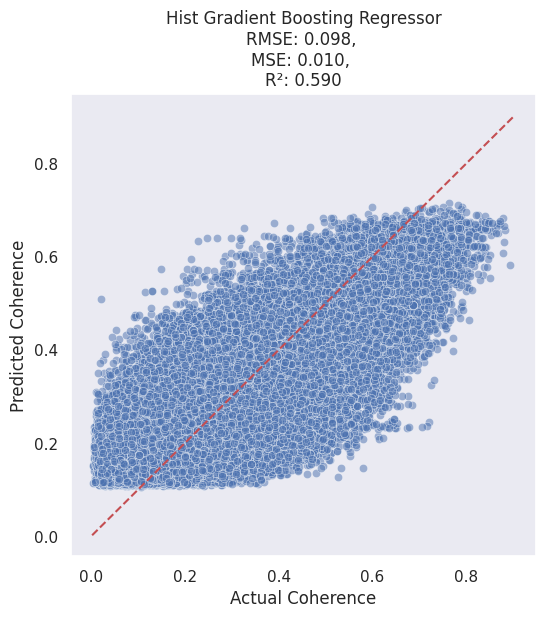

               Feature  Importance
2           avg_precip    1.88e-01
11            max_temp    1.51e-01
9            elevation    8.64e-02
1               aspect    6.42e-02
7       density_change    6.31e-02
15               slope    5.17e-02
4             avg_snow    5.11e-02
12            max_wind    4.56e-02
10     incidence_angle    4.53e-02
6                curve    4.38e-02
19       temp_diff_acq    4.37e-02
5          canopy_2019    3.63e-02
17           swe_accum    2.99e-02
18           temp_diff    2.48e-02
14           mean_wind    2.40e-02
16          swe_ablate    1.44e-02
3             avg_rain    1.09e-02
13           mean_temp    8.95e-03
0       acq_day_precip    7.23e-03
8   diurnal_temp_range    6.35e-03
20        total_posdeg    2.42e-03


In [26]:
# make a random forest model and evaluate
from sklearn.ensemble import HistGradientBoostingRegressor

# redefine features and target for random forest
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Train random forest regressor
hgbr_model = HistGradientBoostingRegressor( 
                                #  max_depth=10,
                                 loss='squared_error',
                                 random_state=42,
                                 )
hgbr_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_hgbr = hgbr_model.predict(X_test)
r2_hgbr = r2_score(y_test, y_pred_hgbr)
rmse_hgbr = root_mean_squared_error(y_test, y_pred_hgbr)
mse_hgbr = mean_squared_error(y_test, y_pred_hgbr)
print(f'R² score for random forest regression: {r2_hgbr:.3f}')
print(f'RMSE for random forest regression: {rmse_hgbr:.3f}')
print(f'MSE for random forest regression: {mse_hgbr:.3f}')

# Plot predicted vs actual coherence for random forest
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_hgbr, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title(f'Hist Gradient Boosting Regressor\nRMSE: {rmse_hgbr:.3f}, \nMSE: {mse_hgbr:.3f}, \nR²: {r2_hgbr:.3f}')
plt.grid()
plt.show() 

# Feature importance from random forest
feature_names = [v for v in data.data_vars if v != 'coherence']
# importances_rf = hgbr_model.feature_importances_
importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
importance_rf_df = importance_rf_df.sort_values('Importance', ascending=False)
print(importance_rf_df)

NameError: name 'y_pred_tree' is not defined

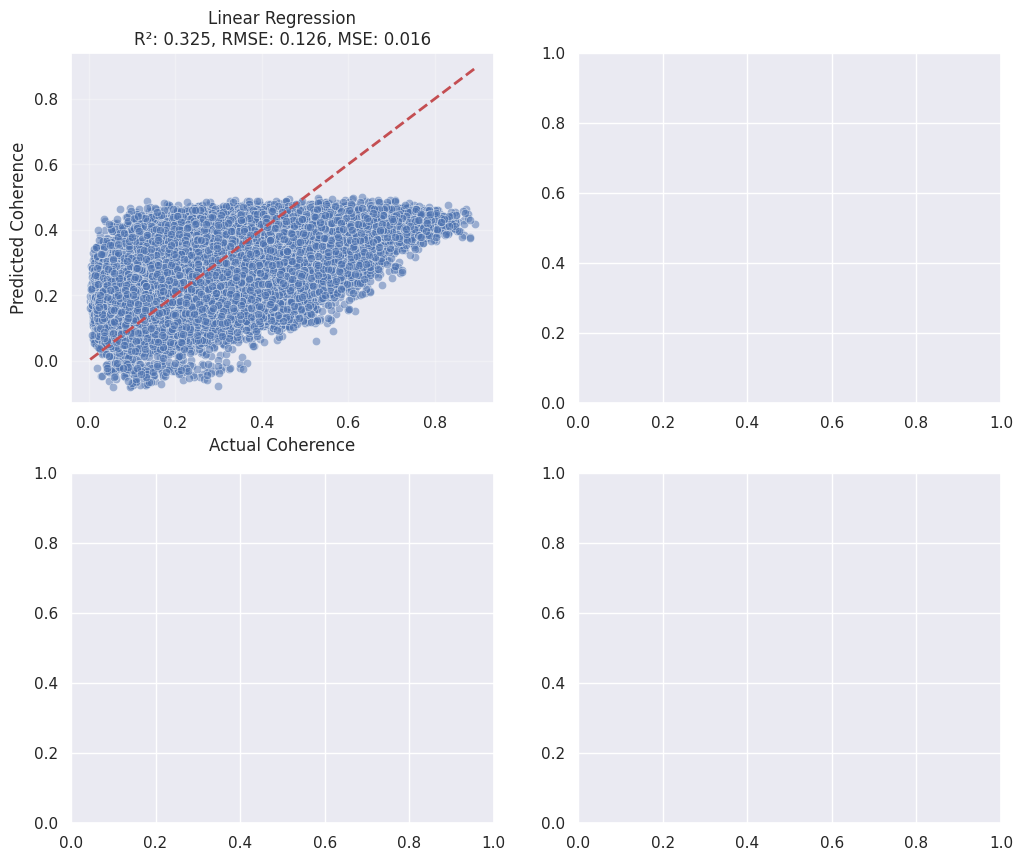

In [21]:
# Create a figure with 4 subplots for model comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1. Linear Regression
ax = axes[0]
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Linear Regression\nR²: {r2:.3f}, RMSE: {rmse:.3f}, MSE: {mse:.3f}')
ax.grid(True, alpha=0.3)

# 2. Decision Tree
ax = axes[1]
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Decision Tree Regression\nR²: {r2_tree:.3f}, RMSE: {rmse_tree:.3f}, MSE: {mse_tree:.3f}')
ax.grid(True, alpha=0.3)

# 3. Random Forest
ax = axes[2]
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Random Forest Regression\nR²: {r2_rf:.3f}, RMSE: {rmse_rf:.3f}, MSE: {mse_rf:.3f}')
ax.grid(True, alpha=0.3)

# 4. Model Comparison Summary (text plot)
ax = axes[3]
ax.axis('off')
summary_text = f"""
MODEL PERFORMANCE COMPARISON

Linear Regression:
    R²: {r2:.3f}
    RMSE: {rmse:.3f}
    MSE: {mse:.3f}

Decision Tree:
    R²: {r2_tree:.3f}
    RMSE: {rmse_tree:.3f}
    MSE: {mse_tree:.3f}

Random Forest:
    R²: {r2_rf:.3f}
    RMSE: {rmse_rf:.3f}
    MSE: {mse_rf:.3f}

Best Model: Random Forest
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Coherence Prediction: Model Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

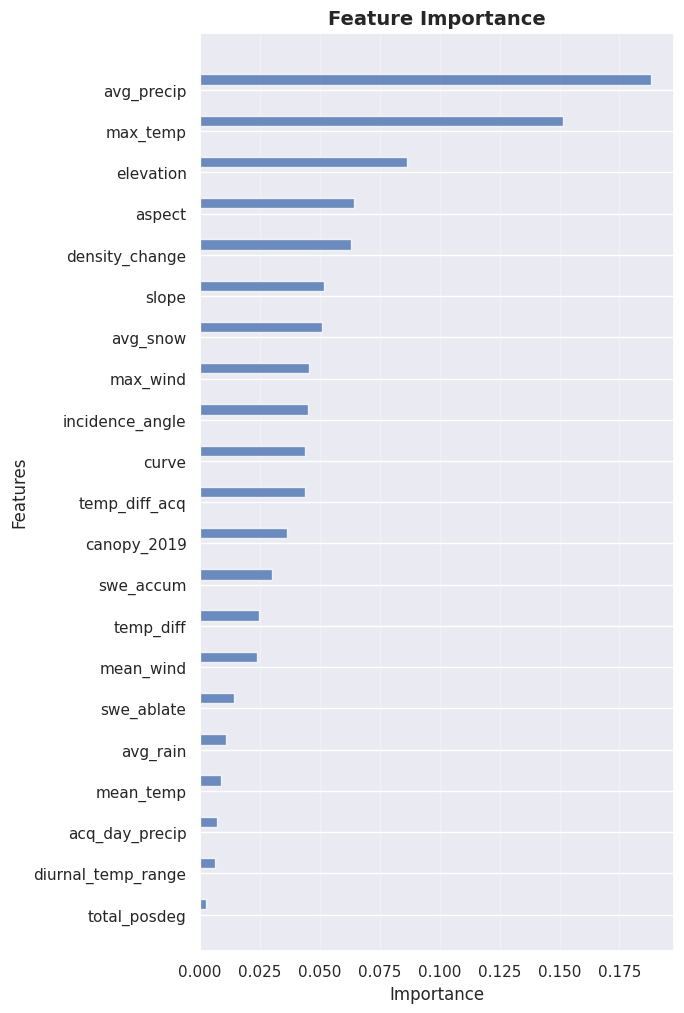

In [62]:
# Create a comparison of feature importances across models
# Keep signed linear coefficients for direction, and absolute values for ranking
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    # 'Linear Coef': coefficients,
    # 'Linear Regression': np.abs(coefficients),
    # 'Decision Tree': importances,
    'Random Forest': importances_rf
})

# Add sign label for linear model direction
# comparison_df['Linear Sign'] = np.where(comparison_df['Linear Coef'] >= 0, 'Positive', 'Negative')

# Calculate mean importance across all models to order features
# comparison_df['Mean Importance'] = comparison_df[['Linear Regression', 'Decision Tree', 'Random Forest']].mean(axis=1)
comparison_df = comparison_df.sort_values('Random Forest', ascending=True)

# Create horizontal bar plot for easier feature name readability
fig, ax = plt.subplots(figsize=(7, 12))

x = np.arange(len(comparison_df))
width = 0.25

# Draw linear bars with one color; use fill pattern to indicate sign
# linear_bars = ax.barh(
#     x - width,
#     comparison_df['Linear Regression'],
#     width,
#     color='green',
#     # edgecolor='black',
#     alpha=0.8,
#     label='Linear Regression (|coef|)'
# )

# Solid hatch for positive, striped hatch for negative
# for bar, coef in zip(linear_bars, comparison_df['Linear Coef']):
#     bar.set_hatch('' if coef >= 0 else '///')

# ax.barh(x, comparison_df['Decision Tree'], width, label='Decision Tree', alpha=0.8)
ax.barh(x + width, comparison_df['Random Forest'], width, label='Random Forest', alpha=0.8)

# Sign legend for linear regression fill style
from matplotlib.patches import Patch
sign_legend = [
    Patch(facecolor='green', hatch='', label='Linear coef: positive (solid)'),
    Patch(facecolor='green', hatch='///', label='Linear coef: negative (striped)')
]

ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(comparison_df['Feature'])

# Stack both legends at the bottom and increase legend text size
legend_models = ax.legend(
    fontsize=13,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=True
)
ax.add_artist(legend_models)
# ax.legend(
#     handles=sign_legend,
#     fontsize=13,
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.16),
#     ncol=2,
#     frameon=True
# )

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# Print the comparison table with sign information
# print("\nFeature Importance Comparison (sorted by mean importance):")
# print(comparison_df[['Feature', 'Linear Coef', 'Linear Sign', 'Linear Regression', 'Decision Tree', 'Random Forest', 'Mean Importance']].to_string(index=False))